# 11 — Tree models: all-vehicle baseline (builds on notebooks 09-11)

Random Forest and XGBoost, tuned, on the selected features from notebook 11, all-vehicle stratified
split — the "advanced" layer on top of notebook 09's logistic regression baseline. **F2 is the
headline tuning/evaluation metric** (recall weighted ~2x precision, per coach feedback), not macro
F1 or plain F1.


In [ ]:
import json

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, f1_score,
                             fbeta_score, make_scorer, precision_score,
                             recall_score)
from sklearn.model_selection import (RandomizedSearchCV, StratifiedKFold,
                                     train_test_split)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

f2_scorer = make_scorer(fbeta_score, beta=2, pos_label=True)

## 1. Load — selected features, same stratified split

In [2]:
df = pd.read_csv(
    "../data/processed/all_vehicles_features.csv", parse_dates=["timestamp"]
)
df = df.sort_values("timestamp").reset_index(drop=True)

with open("../data/processed/selected_feature_cols_all_vehicles.json") as f:
    SELECTED_FEATURE_COLS = json.load(f)

TARGET = "Fault_Within_6h"
df[TARGET] = df[TARGET].astype(bool)

train_df, test_df = train_test_split(
    df, test_size=0.2, stratify=df[TARGET], random_state=42
)
X_train, y_train = train_df[SELECTED_FEATURE_COLS], train_df[TARGET]
X_test, y_test = test_df[SELECTED_FEATURE_COLS], test_df[TARGET]

print(
    f"Train: {len(X_train):,} rows, Test: {len(X_test):,} rows, {len(SELECTED_FEATURE_COLS)} features"
)

Train: 140,067 rows, Test: 35,017 rows, 53 features


## 2. Random Forest — hyperparameter search, scored on F2

Since the split here is stratified/random (not chronological, per the coach's spec for this track),
the search uses `StratifiedKFold`, consistent with the split strategy already chosen — not
`TimeSeriesSplit`, which would only make sense for a chronological split.

**Full-data search:** the search runs on the complete training set (140,067 rows), not a subsample.
An earlier version of this notebook searched on a 40,000-row stratified subsample for compute-time
reasons, then refit on the full set — the coach flagged that as a corner worth removing, so this
version searches on everything the final model is trained on.

In [3]:
rf_param_space = {
    "clf__n_estimators": [80, 120],
    "clf__max_depth": [6, 8, 10],
    "clf__min_samples_leaf": [1, 5, 10],
}

rf_pipeline = Pipeline(
    [
        ("scaler", StandardScaler()),
        (
            "clf",
            RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1),
        ),
    ]
)

skf = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)

rf_search = RandomizedSearchCV(
    rf_pipeline,
    rf_param_space,
    n_iter=3,
    cv=skf,
    scoring=f2_scorer,
    random_state=42,
    n_jobs=-1,
)
rf_search.fit(X_train, y_train)

print(
    f"Best RF params (found on full {len(X_train):,}-row training set): {rf_search.best_params_}"
)
print(f"Best RF CV F2 (full training set): {rf_search.best_score_:.6f}")

# Refit the winning configuration on the full training set (same set the search already used).
rf = Pipeline(
    [
        ("scaler", StandardScaler()),
        (
            "clf",
            RandomForestClassifier(
                **{
                    k.replace("clf__", ""): v for k, v in rf_search.best_params_.items()
                },
                class_weight="balanced",
                random_state=42,
                n_jobs=-1,
            ),
        ),
    ]
)
rf.fit(X_train, y_train)
print("Refit on the full training set.")

Best RF params (found on full 140,067-row training set): {'clf__n_estimators': 80, 'clf__min_samples_leaf': 5, 'clf__max_depth': 8}
Best RF CV F2 (full training set): 0.475530


Refit on the full training set.


## 3. XGBoost — hyperparameter search (same full-data approach), scored on F2

In [4]:
neg, pos = (~y_train).sum(), y_train.sum()
scale_pos_weight = neg / pos
print(f"scale_pos_weight = {neg}/{pos} = {scale_pos_weight:.6f}")

xgb_param_space = {
    "clf__n_estimators": [80, 120],
    "clf__max_depth": [4, 6],
    "clf__learning_rate": [0.05, 0.1, 0.2],
}

xgb_pipeline = Pipeline(
    [
        ("scaler", StandardScaler()),
        (
            "clf",
            XGBClassifier(
                objective="binary:logistic",
                eval_metric="logloss",
                scale_pos_weight=scale_pos_weight,
                random_state=42,
                n_jobs=-1,
            ),
        ),
    ]
)

xgb_search = RandomizedSearchCV(
    xgb_pipeline,
    xgb_param_space,
    n_iter=3,
    cv=skf,
    scoring=f2_scorer,
    random_state=42,
    n_jobs=-1,
)
xgb_search.fit(X_train, y_train)

print(
    f"Best XGB params (found on full {len(X_train):,}-row training set): {xgb_search.best_params_}"
)
print(f"Best XGB CV F2 (full training set): {xgb_search.best_score_:.6f}")

xgb = Pipeline(
    [
        ("scaler", StandardScaler()),
        (
            "clf",
            XGBClassifier(
                **{
                    k.replace("clf__", ""): v
                    for k, v in xgb_search.best_params_.items()
                },
                objective="binary:logistic",
                eval_metric="logloss",
                scale_pos_weight=scale_pos_weight,
                random_state=42,
                n_jobs=-1,
            ),
        ),
    ]
)
xgb.fit(X_train, y_train)
print("Refit on the full training set.")

scale_pos_weight = 127383/12684 = 10.042810


Best XGB params (found on full 140,067-row training set): {'clf__n_estimators': 80, 'clf__max_depth': 6, 'clf__learning_rate': 0.2}
Best XGB CV F2 (full training set): 0.546066


Refit on the full training set.


## 4. Evaluate on the held-out test set

In [5]:
rf_pred = rf.predict(X_test)
xgb_pred = xgb.predict(X_test)

for name, pred in [("Random Forest", rf_pred), ("XGBoost", xgb_pred)]:
    print("=" * 55)
    print(name.upper())
    print("=" * 55)
    print(
        classification_report(
            y_test, pred, labels=[False, True], digits=6, zero_division=0
        )
    )

RANDOM FOREST
              precision    recall  f1-score   support

       False   0.965293  0.693431  0.807083     31846
        True   0.195799  0.749606  0.310496      3171

    accuracy                       0.698518     35017
   macro avg   0.580546  0.721518  0.558789     35017
weighted avg   0.895610  0.698518  0.762114     35017

XGBOOST
              precision    recall  f1-score   support

       False   0.981415  0.767757  0.861537     31846
        True   0.268013  0.853989  0.407985      3171

    accuracy                       0.775566     35017
   macro avg   0.624714  0.810873  0.634761     35017
weighted avg   0.916812  0.775566  0.820465     35017



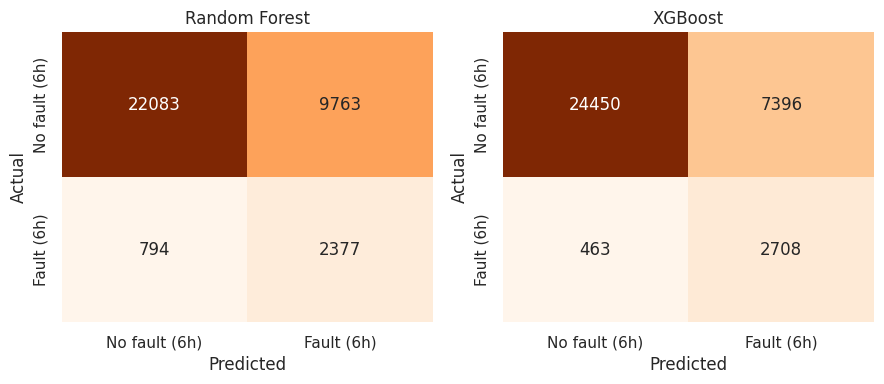

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, pred, name in zip(axes, [rf_pred, xgb_pred], ["Random Forest", "XGBoost"]):
    cm = confusion_matrix(y_test, pred, labels=[False, True])
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Oranges",
        ax=ax,
        cbar=False,
        xticklabels=["No fault (6h)", "Fault (6h)"],
        yticklabels=["No fault (6h)", "Fault (6h)"],
    )
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

### Feature importance — final tuned models (which of the 53 features actually drive predictions)


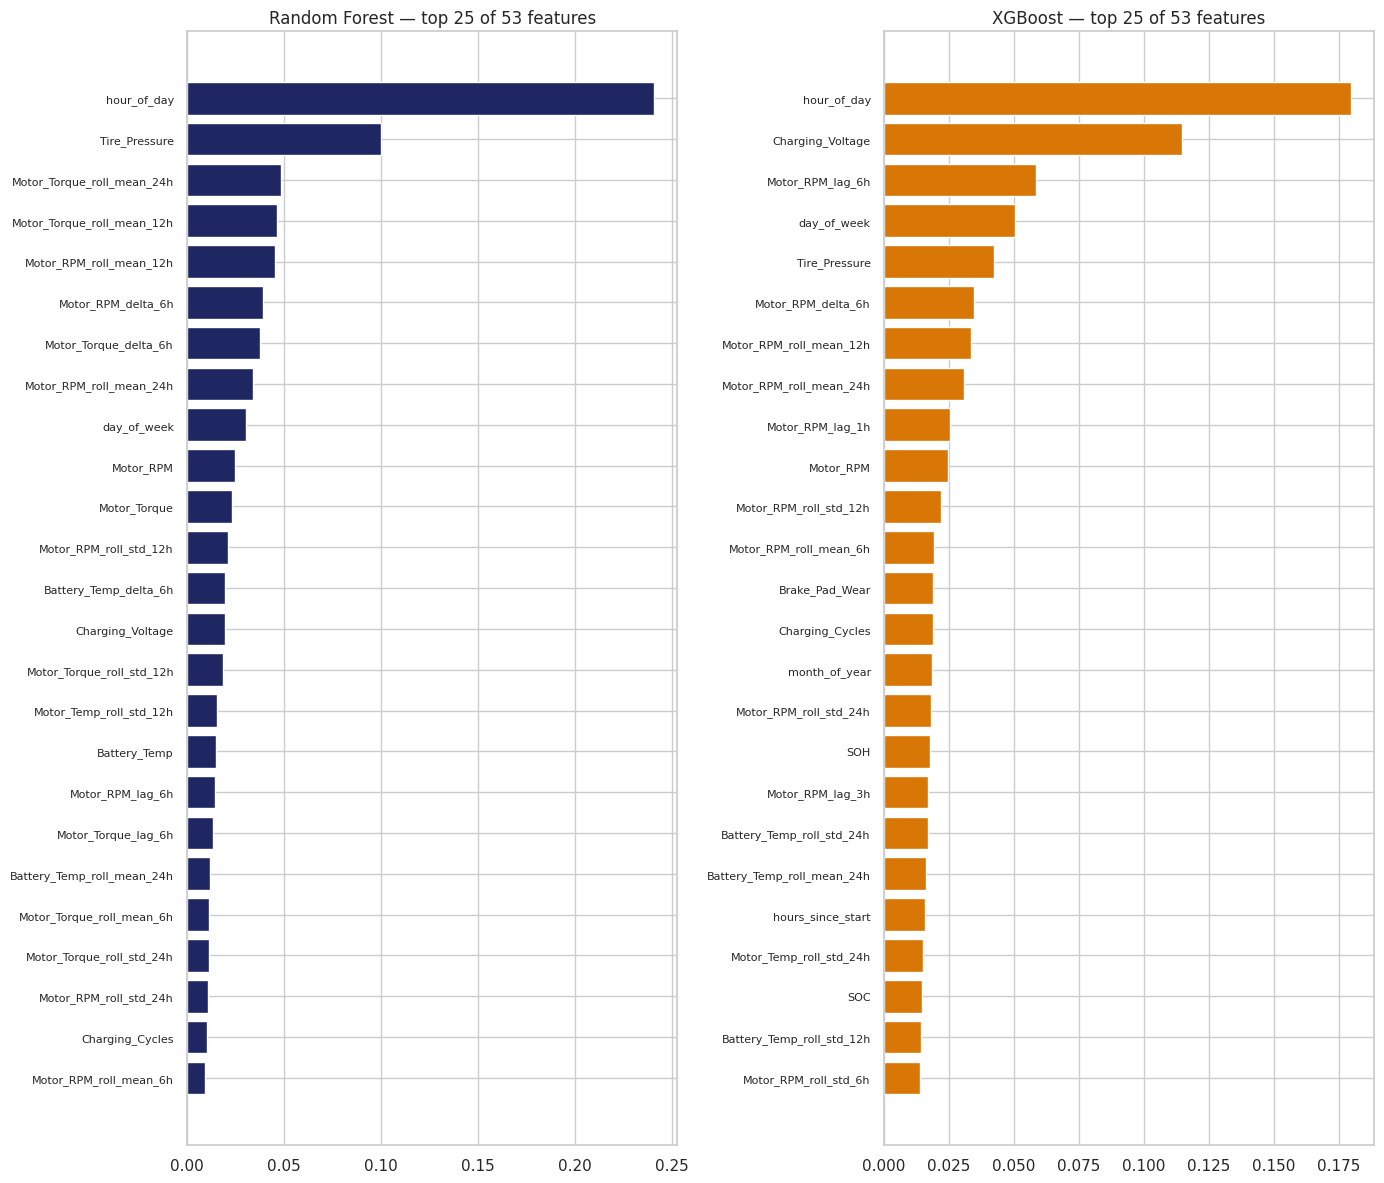

Bottom 10 by XGBoost importance (candidates for a future, tighter feature list):
Motor_Torque_lag_1h           0.0
Motor_Torque_lag_3h           0.0
Motor_Torque_roll_std_24h     0.0
Motor_Torque_roll_mean_24h    0.0
Motor_Torque_roll_std_12h     0.0
Motor_Torque_roll_mean_12h    0.0
Motor_Torque_roll_std_6h      0.0
Motor_Torque_roll_mean_6h     0.0
Motor_Torque_lag_6h           0.0
Motor_Torque_delta_6h         0.0
dtype: float32


In [7]:
rf_importances = pd.Series(
    rf.named_steps["clf"].feature_importances_, index=SELECTED_FEATURE_COLS
)
xgb_importances = pd.Series(
    xgb.named_steps["clf"].feature_importances_, index=SELECTED_FEATURE_COLS
)

fig, axes = plt.subplots(1, 2, figsize=(14, 12))
for ax, importances, name, color in zip(
    axes,
    [rf_importances, xgb_importances],
    ["Random Forest", "XGBoost"],
    ["#1E2761", "#D97706"],
):
    top = importances.sort_values(ascending=True).tail(25)
    ax.barh(top.index, top.values, color=color)
    ax.set_title(f"{name} — top 25 of {len(SELECTED_FEATURE_COLS)} features")
    ax.tick_params(axis="y", labelsize=8)
plt.tight_layout()
plt.show()

print(
    "Bottom 10 by XGBoost importance (candidates for a future, tighter feature list):"
)
print(xgb_importances.sort_values().head(10))

## 5. Final scoreboard — logistic regression (notebook 09) vs. tuned tree models, F2 headline

In [8]:
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder

# Re-fit notebook 09's logistic regression here too, same train/test rows, so every row in this
# scoreboard is computed identically -- no risk of a stale number from an earlier run.
RAW_SENSOR_COLS = [
    "SOC",
    "SOH",
    "Charging_Cycles",
    "Battery_Temp",
    "Motor_RPM",
    "Motor_Torque",
    "Motor_Temp",
    "Brake_Pad_Wear",
    "Charging_Voltage",
    "Tire_Pressure",
]
CONTINUOUS_COLS = [c for c in RAW_SENSOR_COLS if c != "Charging_Voltage"]
preprocessor = ColumnTransformer(
    [
        ("scaler", StandardScaler(), CONTINUOUS_COLS),
        ("onehot", OneHotEncoder(drop="if_binary"), ["Charging_Voltage"]),
    ]
)
logreg = Pipeline(
    [
        ("preprocessor", preprocessor),
        (
            "clf",
            LogisticRegression(class_weight="balanced", max_iter=2000, random_state=42),
        ),
    ]
)
logreg.fit(train_df[RAW_SENSOR_COLS], y_train)
logreg_pred = logreg.predict(test_df[RAW_SENSOR_COLS])

results = {}
for name, pred in [
    ("Logistic Regression (baseline, notebook 09)", logreg_pred),
    ("Random Forest (tuned, selected features)", rf_pred),
    ("XGBoost (tuned, selected features)", xgb_pred),
]:
    results[name] = {
        "recall_fault": recall_score(y_test, pred, pos_label=True, zero_division=0),
        "precision_fault": precision_score(
            y_test, pred, pos_label=True, zero_division=0
        ),
        "F2_fault": fbeta_score(y_test, pred, beta=2, pos_label=True, zero_division=0),
        "F1_fault_secondary": f1_score(y_test, pred, pos_label=True, zero_division=0),
    }

scoreboard = pd.DataFrame(results).T.round(6)

with open("../models/baseline_results_all_vehicles.json", "w") as f:
    json.dump(results, f, indent=2)

scoreboard

,recall_fault,precision_fault,F2_fault,F1_fault_secondary
"Logistic Regression (baseline, notebook 09)",0.516556,0.132987,0.327587,0.211519
"Random Forest (tuned, selected features)",0.749606,0.195799,0.478771,0.310496
"XGBoost (tuned, selected features)",0.853989,0.268013,0.594172,0.407985


In [9]:
import os

import joblib

os.makedirs("../models", exist_ok=True)
joblib.dump(rf, "../models/random_forest_all_vehicles.joblib")
joblib.dump(xgb, "../models/xgboost_all_vehicles.joblib")
print(
    "Saved ../models/random_forest_all_vehicles.joblib and ../models/xgboost_all_vehicles.joblib"
)

Saved ../models/random_forest_all_vehicles.joblib and ../models/xgboost_all_vehicles.joblib


## 6. What this notebook establishes

The all-vehicle track now has its own complete comparison: baseline logistic regression (notebook
08) vs. tuned Random Forest and XGBoost (this notebook), all evaluated on the same stratified test
split, with F2 (recall-weighted) as the headline metric throughout — consistent with every piece of
feedback from today's conversation with the coach.
